# 🃏 BlackjackVAI — Entrenamiento Local v4

**Modelo:** YOLOv8m-seg (segmentación de instancias)  
**Dataset:** BlackjackVAI V4 — 80% train / 20% val (sin test, modo producción)  
**GPU:** Local (RTX 4070 Laptop / cualquier CUDA)  
**Tracking:** MLflow  

### Mejoras respecto a v3
- **Split 80/20** (sin test): las imágenes de test de Roboflow se fusionan en train
- **Augmentation extremo para distancia**: `scale=0.85` permite cartas tan pequeñas como el **15%** del frame, simulando cámara muy lejana
- **Letterbox confirmado** (no resize distorsionado): YOLO usa letterbox por defecto — las cartas no se deforman, se añade padding gris
- **Augmentaciones extra**: perspective, erasing, copy_paste y shear aumentados al máximo
- **Fine-tuning desde `best.pt` v3**: el modelo ya sabe reconocer cartas, solo aprende a verlas pequeñas
- **imgsz inferencia=1280** en el test de webcam para máxima detección a distancia
- Reanuda automáticamente si el entreno se interrumpe (`RESUME = True`)

## 0. Configuración — edita aquí antes de ejecutar

In [11]:
import os
from dotenv import load_dotenv

load_dotenv()

# MLflow — mismo mlflow.db que v3, experimento nuevo blackjackvai-v4
MLFLOW_EXPERIMENT = "blackjackvai-v4"
MLFLOW_DB = "sqlite:////home/dmore/code/Máster IA/01.-MASTER COURSES/12.- MLOPS Y AI BI/mlops_env/mlflow.db"
os.environ["MLFLOW_TRACKING_URI"]    = MLFLOW_DB
os.environ["MLFLOW_EXPERIMENT_NAME"] = MLFLOW_EXPERIMENT

# Roboflow
ROBOFLOW_API_KEY   = os.environ["ROBOFLOW_API_KEY"]
ROBOFLOW_WORKSPACE = "javiers-workspace-q8mnr"
ROBOFLOW_PROJECT   = "blackjackvai"
ROBOFLOW_VERSION   = 4

from pathlib import Path
BASE_DIR    = Path(".").resolve()
DATASET_DIR = BASE_DIR / f"BlackjackVAI-{ROBOFLOW_VERSION}"
WORKDIR     = BASE_DIR / "training_runs"
MODELS_DIR  = BASE_DIR / "models"

RUN_NAME    = "yolo8m_seg_v4"
# Partimos de best.pt de v3 — el modelo ya conoce las cartas (mAP50=0.954)
# El augmentation agresivo de v4 le enseña a detectarlas pequeñas (distancia)
# sin tener que reaprender la tarea desde cero (transfer desde COCO)
MODEL_BASE  = "models/best.pt"
EPOCHS      = 120
IMGSZ       = 640
BATCH       = 8
PATIENCE    = 25
SEED        = 42
SAVE_PERIOD = 10
RESUME      = True

DATA_YAML = DATASET_DIR / "data.yaml"
RUN_DIR   = WORKDIR / "runs" / RUN_NAME
BEST_PT   = RUN_DIR / "weights" / "best.pt"
LAST_PT   = RUN_DIR / "weights" / "last.pt"

WORKDIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Dataset dir         : {DATASET_DIR}")
print(f"Modelo base         : {MODEL_BASE}  ← fine-tuning desde v3")
print(f"Run dir             : {RUN_DIR}")
print(f"MLflow DB           : {MLFLOW_DB}")
print(f"MLflow experiment   : {MLFLOW_EXPERIMENT}")
print(f"Resume              : {RESUME}")

Dataset dir         : /home/dmore/code/Máster IA/01.-MASTER COURSES/10.- VISIÓN ARTIFICIAL AVANZADA/blackjack-VAI/BlackjackVAI-4
Modelo base         : models/best.pt  ← fine-tuning desde v3
Run dir             : /home/dmore/code/Máster IA/01.-MASTER COURSES/10.- VISIÓN ARTIFICIAL AVANZADA/blackjack-VAI/training_runs/runs/yolo8m_seg_v4
MLflow DB           : sqlite:////home/dmore/code/Máster IA/01.-MASTER COURSES/12.- MLOPS Y AI BI/mlops_env/mlflow.db
MLflow experiment   : blackjackvai-v4
Resume              : True


## 1. Dependencias y verificación de GPU

In [12]:
import torch

DEVICE = 0 if torch.cuda.is_available() else "cpu"
if torch.cuda.is_available():
    gpu = torch.cuda.get_device_properties(0)
    vram_gb = gpu.total_memory / 1e9
    print(f"GPU : {gpu.name}  |  VRAM: {vram_gb:.1f} GB")
    if vram_gb < 6:
        print("AVISO: menos de 6 GB VRAM — considera BATCH=4")
else:
    print("AVISO: no se detectó GPU — el entreno será muy lento en CPU")

import ultralytics, mlflow
print(f"Ultralytics {ultralytics.__version__} | MLflow {mlflow.__version__} | PyTorch {torch.__version__}")

GPU : NVIDIA GeForce RTX 4070 Laptop GPU  |  VRAM: 8.6 GB
Ultralytics 8.4.45 | MLflow 3.10.0 | PyTorch 2.10.0+cu128


## 2. Descarga del dataset V4

In [13]:
if DATA_YAML.exists():
    print(f"Dataset ya existe en {DATASET_DIR} — saltando descarga.")
else:
    print("Descargando dataset V4 desde Roboflow...")
    from roboflow import Roboflow
    rf = Roboflow(api_key=ROBOFLOW_API_KEY)
    project = rf.workspace(ROBOFLOW_WORKSPACE).project(ROBOFLOW_PROJECT)
    dataset = project.version(ROBOFLOW_VERSION).download("yolov8", location=str(DATASET_DIR))
    print(f"Dataset descargado en: {dataset.location}")

Dataset ya existe en /home/dmore/code/Máster IA/01.-MASTER COURSES/10.- VISIÓN ARTIFICIAL AVANZADA/blackjack-VAI/BlackjackVAI-4 — saltando descarga.


## 3. Split 80/20 — fusionar test en train

Roboflow descarga con split 80/10/10. Para producción (sin test holdout) fusionamos
las imágenes y labels de `test/` en `train/`, quedando **80% train / 20% val**.

In [15]:
import shutil

test_img_dir = DATASET_DIR / "test" / "images"
test_lbl_dir = DATASET_DIR / "test" / "labels"
train_img_dir = DATASET_DIR / "train" / "images"
train_lbl_dir = DATASET_DIR / "train" / "labels"

merged = 0
if test_img_dir.exists():
    for img in test_img_dir.glob("*.*"):
        dest = train_img_dir / img.name
        if not dest.exists():
            shutil.copy2(img, dest)
            merged += 1
    for lbl in test_lbl_dir.glob("*.txt"):
        dest = train_lbl_dir / lbl.name
        if not dest.exists():
            shutil.copy2(lbl, dest)
    print(f"Fusionadas {merged} imágenes de test → train")
else:
    print("Carpeta test/ no encontrada — puede que ya se fusionó o el split ya era 80/20")

for split in ["train", "val", "test"]:
    d = DATASET_DIR / split / "images"
    if d.exists():
        n = len(list(d.glob("*.*")))
        print(f"  {split}: {n} imágenes")

Carpeta test/ no encontrada — puede que ya se fusionó o el split ya era 80/20
  train: 2574 imágenes
  val: 644 imágenes


## 4. Preparar data.yaml (sin split test)

In [16]:
import yaml

with open(DATA_YAML) as f:
    data = yaml.safe_load(f)

data["path"] = str(DATASET_DIR.resolve())

# Normalizar 'valid' → 'val'
for key in list(data.keys()):
    if key == "valid":
        val = data.pop(key)
        data["val"] = str(val).replace("valid/", "val/").replace("/valid/", "/val/")

# Renombrar carpeta en disco si hace falta
valid_dir = DATASET_DIR / "valid"
val_dir   = DATASET_DIR / "val"
if valid_dir.exists() and not val_dir.exists():
    shutil.copytree(valid_dir, val_dir)
    print("Carpeta 'valid' copiada a 'val'")

# Eliminar referencia a test del yaml — no usamos test split
data.pop("test", None)

with open(DATA_YAML, "w") as f:
    yaml.safe_dump(data, f, sort_keys=False, allow_unicode=True)

names = data["names"] if isinstance(data["names"], list) else list(data["names"].values())
print(f"Clases ({data['nc']}): {names[:8]} ...")
print(f"Train : {data.get('train')}")
print(f"Val   : {data.get('val')}")
print(f"Test  : eliminado del yaml (split de producción)")

# Limpiar caches viejas
for cache in DATASET_DIR.rglob("*.cache"):
    cache.unlink()
    print(f"Cache eliminada: {cache}")

Clases (54): ['10 Clubs', '10 Diamonds', '10 Hearts', '10 Spades', '2 Clubs', '2 Diamonds', '2 Hearts', '2 Spades'] ...
Train : ../train/images
Val   : ../valid/images
Test  : eliminado del yaml (split de producción)
Cache eliminada: /home/dmore/code/Máster IA/01.-MASTER COURSES/10.- VISIÓN ARTIFICIAL AVANZADA/blackjack-VAI/BlackjackVAI-4/valid/labels.cache
Cache eliminada: /home/dmore/code/Máster IA/01.-MASTER COURSES/10.- VISIÓN ARTIFICIAL AVANZADA/blackjack-VAI/BlackjackVAI-4/train/labels.cache


## 5. Limpiar etiquetas mixtas detect/segment

In [17]:
def fix_labels(label_dir: Path) -> int:
    n_fixed = 0
    for lbl in label_dir.glob("*.txt"):
        lines = lbl.read_text(encoding="utf-8").splitlines()
        seg_lines = [
            ln for ln in lines
            if ln.strip() and
               len(ln.strip().split()) > 5 and
               (len(ln.strip().split()) - 1) % 2 == 0
        ]
        if len(seg_lines) != len([l for l in lines if l.strip()]):
            lbl.write_text("\n".join(seg_lines), encoding="utf-8")
            n_fixed += 1
    return n_fixed

for split in ["train", "val"]:
    lbl_dir = DATASET_DIR / split / "labels"
    if lbl_dir.exists():
        n = fix_labels(lbl_dir)
        print(f"{split}: {n} ficheros corregidos")

print("Labels OK.")

train: 0 ficheros corregidos
val: 0 ficheros corregidos
Labels OK.


## 6. Verificación letterbox (no distorsión de cartas)

YOLO usa **letterbox** por defecto (`rect=False`): las imágenes no cuadradas se **rellenan con padding gris** hasta llegar a `IMGSZ×IMGSZ` sin estirar ni aplastar las cartas. Esto es correcto para cartas (aspect ratio ~0.7).

Un resize directo a 640×640 distorsionaría las cartas y confundiría al modelo con formas que no existen en producción. Con letterbox el modelo aprende la forma real de la carta independientemente del tamaño.

Esta celda muestra una muestra para confirmarlo visualmente.

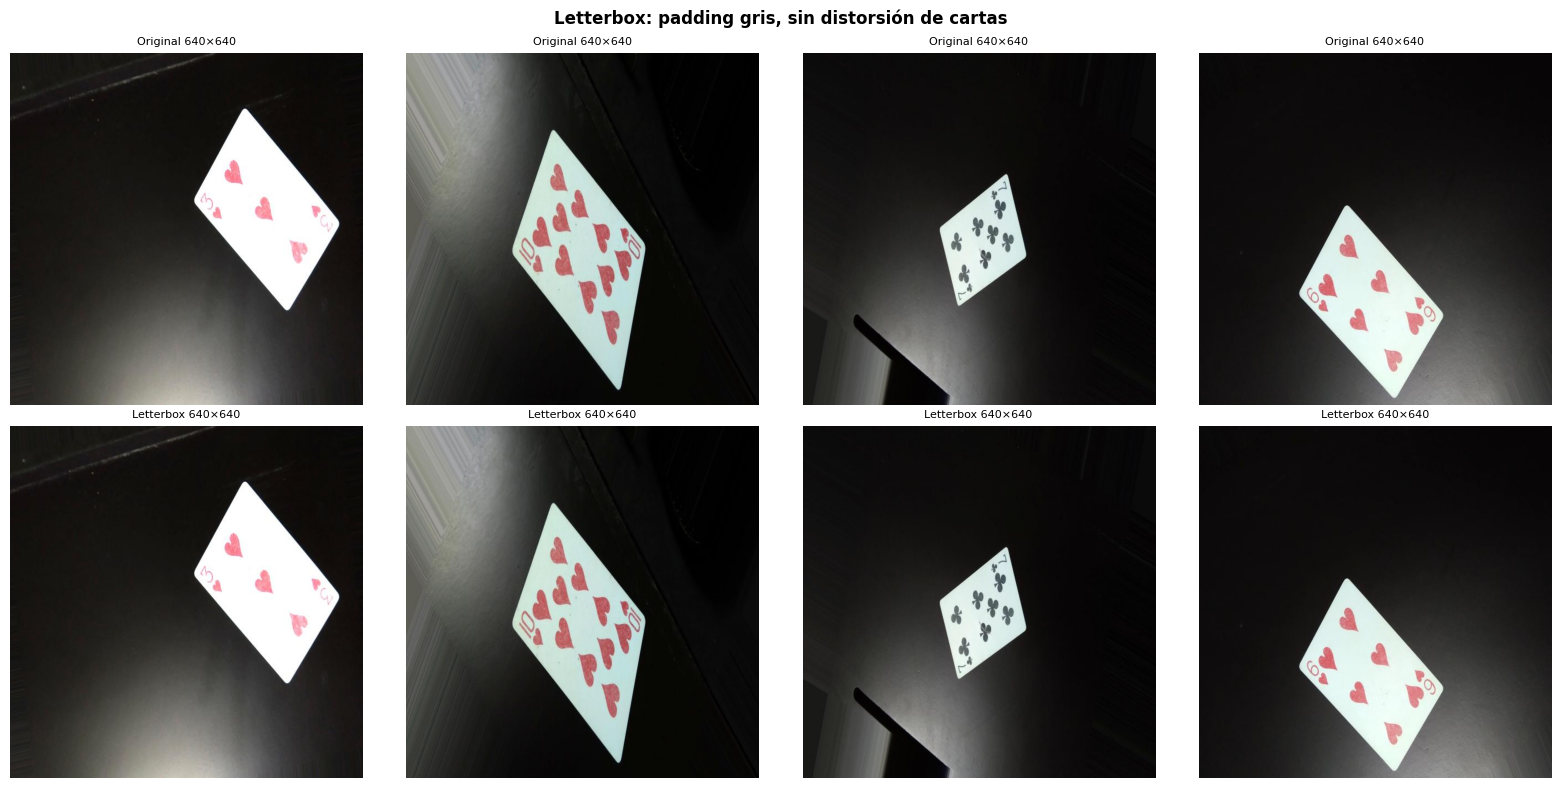

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

random.seed(SEED)

def letterbox_preview(img_path: Path, target: int = 640):
    """Simula el letterbox que aplica YOLO internamente."""
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    scale = target / max(h, w)
    nh, nw = int(h * scale), int(w * scale)
    resized = cv2.resize(img, (nw, nh))
    pad_top  = (target - nh) // 2
    pad_left = (target - nw) // 2
    canvas = np.full((target, target, 3), 114, dtype=np.uint8)
    canvas[pad_top:pad_top+nh, pad_left:pad_left+nw] = resized
    return img, canvas, (h, w)

train_imgs = sorted((DATASET_DIR / "train" / "images").glob("*.*"))
samples = random.sample(train_imgs, min(4, len(train_imgs)))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, p in enumerate(samples):
    orig, lb, (h, w) = letterbox_preview(p)
    axes[0, i].imshow(orig)
    axes[0, i].set_title(f"Original {w}×{h}", fontsize=8)
    axes[0, i].axis("off")
    axes[1, i].imshow(lb)
    axes[1, i].set_title(f"Letterbox 640×640", fontsize=8)
    axes[1, i].axis("off")

plt.suptitle("Letterbox: padding gris, sin distorsión de cartas", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 6b. Simulación de distancia — cómo ve el modelo las cartas a distintas escalas

Con `scale=0.85` el modelo verá cartas desde el **15% hasta el 185%** de su tamaño original.
Esta celda muestra cómo queda una carta real en el frame a cada nivel de escala,
para tener intuición de a qué distancia física equivale cada porcentaje.

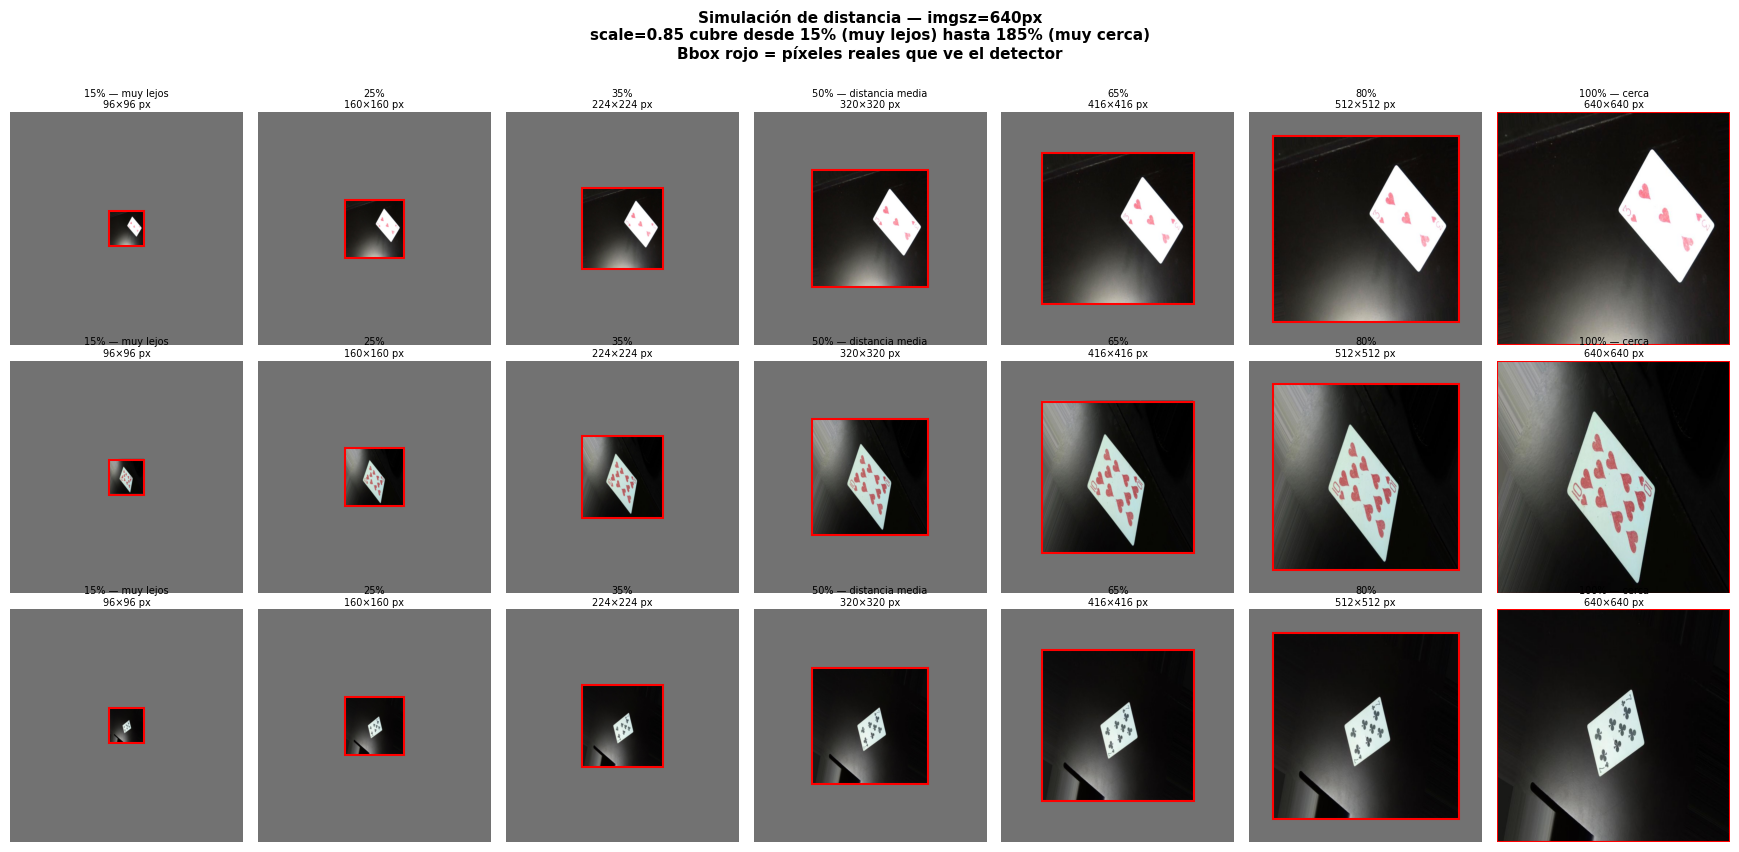


  Escala |   Carta aprox (px) | Equivalencia
-------------------------------------------------------
     15% |         72 px alto | 15% — muy lejos
     25% |        120 px alto | 25%
     35% |        168 px alto | 35%
     50% |        240 px alto | 50% — distancia media
     65% |        312 px alto | 65%
     80% |        384 px alto | 80%
    100% |        480 px alto | 100% — cerca


In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
from pathlib import Path

random.seed(SEED)

# Escalas a visualizar: desde muy lejos (15%) hasta cerca (100%)
SCALES      = [0.15, 0.25, 0.35, 0.50, 0.65, 0.80, 1.00]
SCALE_LABELS = ["15% — muy lejos", "25%", "35%", "50% — distancia media",
                "65%", "80%", "100% — cerca"]
CANVAS_SIZE = 640  # imgsz de entrenamiento

def place_card_at_scale(card_img: np.ndarray, scale: float, canvas_size: int = 640) -> np.ndarray:
    """Coloca la carta escalada y centrada sobre un canvas gris (como haría YOLO con scale aug)."""
    h, w = card_img.shape[:2]
    new_w = max(1, int(w * scale))
    new_h = max(1, int(h * scale))
    # Mantener dentro del canvas
    new_w = min(new_w, canvas_size)
    new_h = min(new_h, canvas_size)
    resized = cv2.resize(card_img, (new_w, new_h), interpolation=cv2.INTER_AREA)
    canvas = np.full((canvas_size, canvas_size, 3), 114, dtype=np.uint8)  # gris YOLO
    y0 = (canvas_size - new_h) // 2
    x0 = (canvas_size - new_w) // 2
    canvas[y0:y0+new_h, x0:x0+new_w] = resized
    return canvas, (x0, y0, new_w, new_h)

# Elegir 3 cartas distintas para mostrar
train_imgs = sorted((DATASET_DIR / "train" / "images").glob("*.*"))
sample_cards = random.sample(train_imgs, min(3, len(train_imgs)))

fig, axes = plt.subplots(len(sample_cards), len(SCALES),
                         figsize=(len(SCALES) * 2.5, len(sample_cards) * 2.8))

for row, img_path in enumerate(sample_cards):
    card = cv2.imread(str(img_path))
    card = cv2.cvtColor(card, cv2.COLOR_BGR2RGB)

    for col, (scale, label) in enumerate(zip(SCALES, SCALE_LABELS)):
        canvas, (x0, y0, nw, nh) = place_card_at_scale(card, scale, CANVAS_SIZE)
        ax = axes[row, col]
        ax.imshow(canvas)

        # Dibuja bbox rojo alrededor de la carta
        rect = patches.Rectangle((x0, y0), nw, nh,
                                  linewidth=1.5, edgecolor='red', facecolor='none')
        ax.add_patch(rect)

        # Info de tamaño en píxeles
        ax.set_title(f"{label}\n{nw}×{nh} px", fontsize=7, pad=3)
        ax.axis("off")

        if col == 0:
            ax.set_ylabel(img_path.stem[:18], fontsize=7, rotation=0,
                          labelpad=60, va='center')

plt.suptitle(
    f"Simulación de distancia — imgsz={CANVAS_SIZE}px\n"
    f"scale=0.85 cubre desde 15% (muy lejos) hasta 185% (muy cerca)\n"
    f"Bbox rojo = píxeles reales que ve el detector",
    fontsize=11, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()

# Tabla resumen de píxeles por escala
print(f"\n{'Escala':>8} | {'Carta aprox (px)':>18} | Equivalencia")
print("-" * 55)
ref_h = 480  # altura media de una carta en el dataset
for scale, label in zip(SCALES, SCALE_LABELS):
    px = int(ref_h * scale)
    print(f"{scale*100:>7.0f}% | {px:>10d} px alto | {label}")

## 7. Visualización del dataset (9 muestras)

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


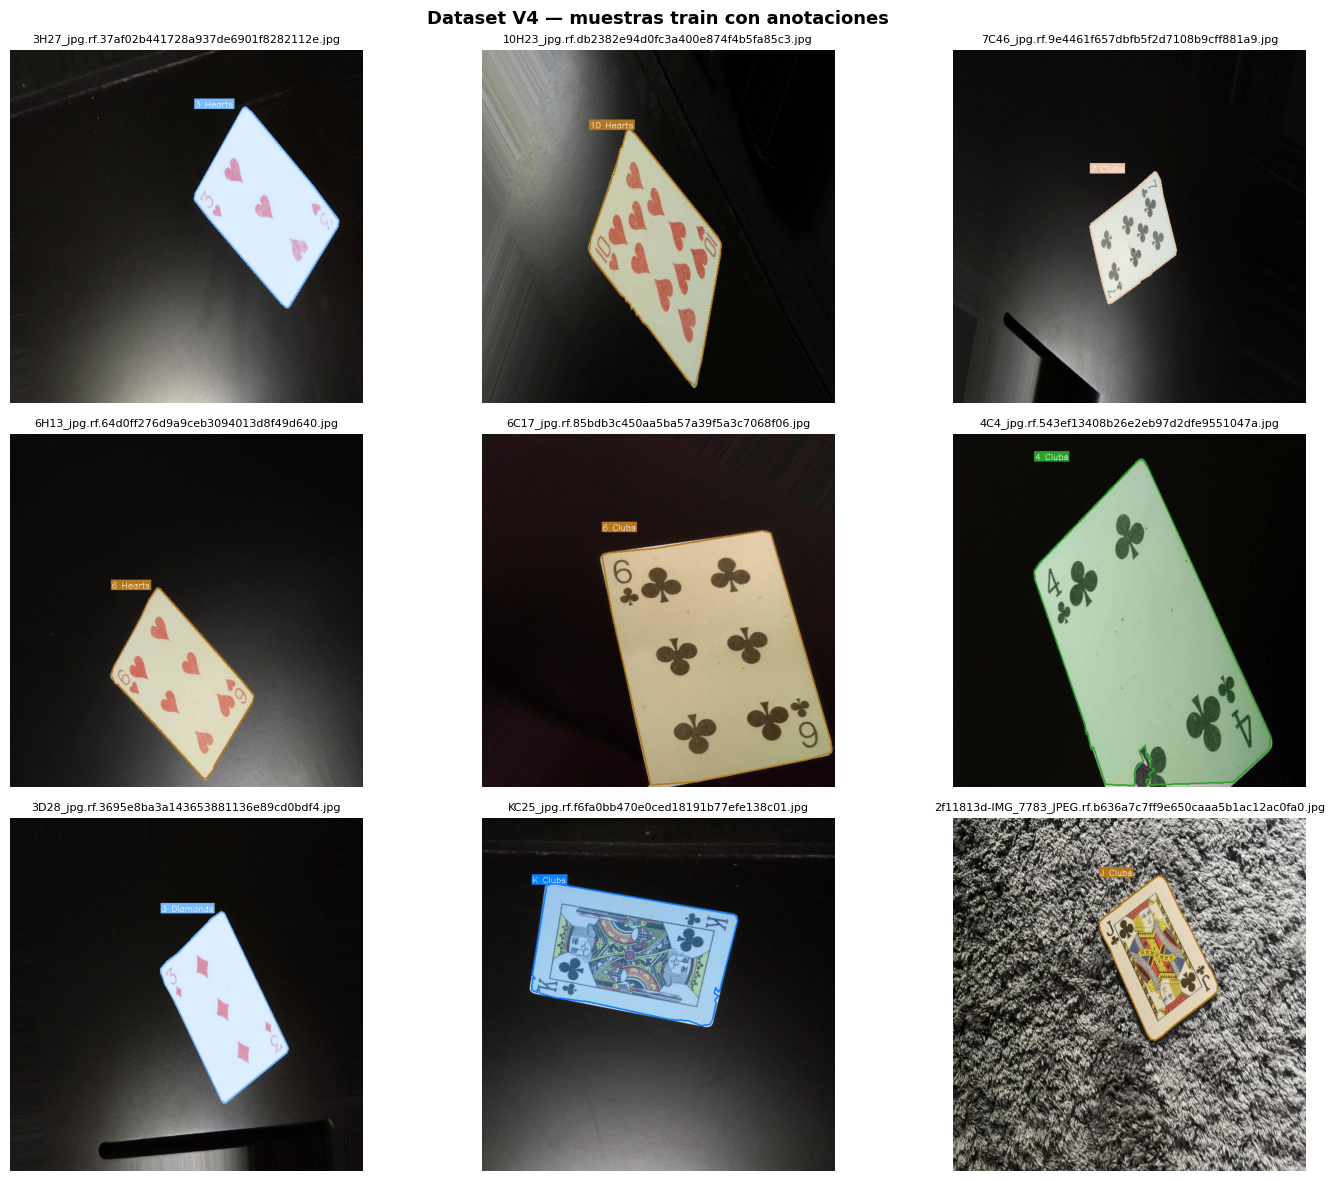

In [20]:
import matplotlib.pyplot as plt

random.seed(SEED)
CMAP = plt.cm.get_cmap("tab20", len(names))

def bgr_color(cls_id):
    r, g, b, _ = CMAP(cls_id % 20)
    return (int(b*255), int(g*255), int(r*255))

def draw_sample(img_path: Path, lbl_path: Path):
    img = cv2.imread(str(img_path))
    if img is None: return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    if not lbl_path.exists(): return img
    for ln in lbl_path.read_text(encoding="utf-8").splitlines():
        toks = ln.strip().split()
        if not toks or len(toks) < 7: continue
        cls_id = int(float(toks[0]))
        coords = np.array(list(map(float, toks[1:])), dtype=np.float32).reshape(-1, 2)
        coords[:, 0] *= w; coords[:, 1] *= h
        pts = coords.astype(np.int32)
        color = bgr_color(cls_id)
        if len(pts) >= 3:
            ov = img.copy()
            cv2.fillPoly(ov, [pts], color)
            img = cv2.addWeighted(ov, 0.25, img, 0.75, 0)
            cv2.polylines(img, [pts], True, color, 2)
        x0, y0 = pts.min(axis=0)
        label = names[cls_id] if cls_id < len(names) else f"cls_{cls_id}"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        y0c = max(y0, th + 4)
        cv2.rectangle(img, (x0, y0c-th-4), (x0+tw+2, y0c+2), color, -1)
        cv2.putText(img, label, (x0+1, y0c-1), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)
    return img

train_img_dir = DATASET_DIR / "train" / "images"
train_imgs    = sorted(train_img_dir.glob("*.*"))
samples       = random.sample(train_imgs, min(9, len(train_imgs)))

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, img_path in zip(axes.flatten(), samples):
    lbl_path = img_path.parent.parent / "labels" / f"{img_path.stem}.txt"
    ann = draw_sample(img_path, lbl_path)
    if ann is not None:
        ax.imshow(ann)
        ax.set_title(img_path.name, fontsize=8)
    ax.axis("off")
plt.suptitle("Dataset V4 — muestras train con anotaciones", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Configurar MLflow

In [21]:
from ultralytics import settings as yolo_settings

yolo_settings.update({"mlflow": True})

print(f"YOLO mlflow activo  : {yolo_settings.get('mlflow')}")
print(f"MLflow URI          : {os.environ['MLFLOW_TRACKING_URI']}")
print(f"MLflow experiment   : {os.environ['MLFLOW_EXPERIMENT_NAME']}")
print("Todo listo — ejecuta la celda de entrenamiento.")

YOLO mlflow activo  : True
MLflow URI          : sqlite:////home/dmore/code/Máster IA/01.-MASTER COURSES/12.- MLOPS Y AI BI/mlops_env/mlflow.db
MLflow experiment   : blackjackvai-v4
Todo listo — ejecuta la celda de entrenamiento.


## 9. Entrenamiento — Augmentation extremo para distancia

### Estrategia para detección a distancia (cartas pequeñas)

El problema de v3 era que entrenó principalmente con cartas grandes (cámara cerca). Las siguientes estrategias lo corrigen:

| Parámetro | v3 | v4 | Razón |
|-----------|----|----|-------|
| `scale` | 0.30 | **0.85** | Cartas desde el **15%** del tamaño original → cámara muy lejana |
| `mosaic` | 1.0 | **1.0** | Combina 4 imágenes → objetos aún más pequeños en el frame |
| `copy_paste` | 0.20 | **0.60** | Pega cartas sobre otros fondos a escalas variadas |
| `erasing` | — | **0.50** | Oclusión agresiva (manos, fichas, otras cartas) |
| `perspective` | — | **0.001** | Simula ángulo de la webcam respecto a la mesa |
| `degrees` | 10 | **20** | Más rotación (cartas no siempre alineadas) |
| `shear` | 2.0 | **8.0** | Perspectiva lateral agresiva |
| `hsv_s` | 0.70 | **0.90** | Saturación — distintas iluminaciones |
| `hsv_v` | 0.40 | **0.60** | Brillo — sombras y sobreexposición |
| `close_mosaic` | 10 | **20** | Más epochs con mosaic antes de desactivarlo |
| `mixup` | 0.15 | **0.25** | Más mezcla entre imágenes |

### Nota sobre resolución webcam (1280×720)
La webcam emite a 1280×720 (16:9). YOLO aplica letterbox a 640×640 en entrenamiento.
En inferencia se usa `imgsz=1280` para aprovechar la resolución completa de la webcam.
Esto permite detectar cartas pequeñas que a 640 quedarían en muy pocos píxeles.

### Fine-tuning desde best.pt v3
`lr0=0.001` (10× menor que el default) para no destruir lo aprendido en v3.
El modelo ya sabe reconocer las 54 clases — solo necesita aprender a hacerlo a distancia.

In [ ]:
from ultralytics import YOLO

resuming = RESUME and LAST_PT.exists()

if resuming:
    print(f"Reanudando desde: {LAST_PT}")
    model = YOLO(str(LAST_PT))
else:
    print(f"Fine-tuning desde: {MODEL_BASE}")
    model = YOLO(MODEL_BASE)

train_kwargs = dict(
    data         = str(DATA_YAML),
    task         = "segment",
    epochs       = EPOCHS,
    imgsz        = IMGSZ,
    batch        = BATCH,
    device       = DEVICE,
    workers      = 4,
    seed         = SEED,
    pretrained   = True,
    amp          = True,
    cache        = False,
    cos_lr       = True,
    lr0          = 0.001,       # LR bajo — fine-tuning, no destruir v3
    lrf          = 0.01,
    warmup_epochs= 3,
    patience     = PATIENCE,
    save_period  = SAVE_PERIOD,
    plots        = True,
    save         = True,
    project      = str(WORKDIR / "runs"),
    name         = RUN_NAME,
    exist_ok     = True,
    rect         = False,       # letterbox — sin distorsión de cartas
    # ── Augmentation extremo para robustez a distancia ─────────────
    # scale=0.85 → cartas desde el 15% hasta el 185% del tamaño original
    # A 640px de imgsz: mínimo ~96px de carta → equivale a cámara muy lejana
    # Combinado con mosaic las cartas pueden aparecer aún más pequeñas
    hsv_h        = 0.02,
    hsv_s        = 0.90,        # saturación máxima — distintas iluminaciones
    hsv_v        = 0.60,        # brillo — sombras fuertes y sobreexposición
    degrees      = 20.0,        # rotación ±20°
    translate    = 0.20,        # desplazamiento ±20%
    scale        = 0.85,        # ← AUMENTADO: [0.15x–1.85x] rango de escala
    shear        = 8.0,         # perspectiva lateral agresiva
    perspective  = 0.001,       # distorsión perspectiva — ángulo de cámara
    flipud       = 0.25,
    fliplr       = 0.50,
    mosaic       = 1.0,         # 4 imágenes combinadas → objetos más pequeños
    mixup        = 0.25,
    copy_paste   = 0.60,        # ← AUMENTADO: pega cartas a escalas variadas
    erasing      = 0.50,        # ← AUMENTADO: oclusión agresiva
    close_mosaic = 20,          # ← AUMENTADO: más epochs con mosaic
    overlap_mask = True,
    mask_ratio   = 4,
)

if resuming:
    results = model.train(resume=True)
else:
    results = model.train(**train_kwargs)

RUN_DIR_FINAL = Path(model.trainer.save_dir)
BEST_PT_FINAL = RUN_DIR_FINAL / "weights" / "best.pt"
LAST_PT_FINAL = RUN_DIR_FINAL / "weights" / "last.pt"

print(f"\nEntrenamiento completado.")
print(f"best.pt → {BEST_PT_FINAL}")
print(f"last.pt → {LAST_PT_FINAL}")

## 10. Curvas de entrenamiento

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results_csv = RUN_DIR_FINAL / "results.csv"
if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    for col, lbl in [("train/box_loss", "train"), ("val/box_loss", "val")]:
        if col in df.columns: axes[0].plot(df["epoch"], df[col], label=lbl)
    axes[0].set_title("Box Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

    for col, lbl in [("metrics/mAP50(B)", "mAP50"), ("metrics/mAP50-95(B)", "mAP50-95")]:
        if col in df.columns: axes[1].plot(df["epoch"], df[col], label=lbl)
    axes[1].set_title("mAP — Bounding Box"); axes[1].set_xlabel("Epoch"); axes[1].legend()

    for col, lbl in [("metrics/mAP50(M)", "mAP50"), ("metrics/mAP50-95(M)", "mAP50-95")]:
        if col in df.columns: axes[2].plot(df["epoch"], df[col], label=lbl)
    axes[2].set_title("mAP — Máscara"); axes[2].set_xlabel("Epoch"); axes[2].legend()

    plt.suptitle("Curvas de entrenamiento — BlackjackVAI V4", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("results.csv no encontrado — ejecuta la celda de entrenamiento primero.")

## 11. Evaluación sobre validación + log MLflow

In [ ]:
import mlflow
import re
from ultralytics import YOLO
from datetime import datetime

def sanitize(key):
    return re.sub(r'[^a-zA-Z0-9_\-\. :/]', '_', key)

model = YOLO(str(BEST_PT_FINAL))

# Evaluación sobre val (no hay test en v4)
m = model.val(
    data=str(DATA_YAML),
    split="val",
    imgsz=IMGSZ,
    conf=0.5,
    iou=0.45,
    plots=True,
    save_json=True,
)

print(f"\nmAP50      (box) : {m.box.map50:.4f}")
print(f"mAP50-95   (box) : {m.box.map:.4f}")
print(f"mAP50      (mask): {m.seg.map50:.4f}")
print(f"mAP50-95   (mask): {m.seg.map:.4f}")

# Log en MLflow
mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])
mlflow.set_experiment(MLFLOW_EXPERIMENT)

with mlflow.start_run(run_name=f"val_eval_{datetime.now():%Y%m%d_%H%M}"):
    mlflow.log_metrics({
        "val/mAP50_box":     m.box.map50,
        "val/mAP50-95_box":  m.box.map,
        "val/mAP50_mask":    m.seg.map50,
        "val/mAP50-95_mask": m.seg.map,
        "val/precision":     m.box.mp,
        "val/recall":        m.box.mr,
    })

    # Métricas completas sanitizadas
    for k, v in m.results_dict.items():
        try:
            mlflow.log_metric(f"val_{sanitize(k)}", float(v))
        except (TypeError, ValueError):
            pass

    # Hiperparámetros de augmentation para trazabilidad
    mlflow.log_params({
        "scale":       0.70,
        "copy_paste":  0.50,
        "erasing":     0.40,
        "perspective": 0.0008,
        "mosaic":      1.0,
        "imgsz_train": IMGSZ,
        "imgsz_infer": 1280,
        "split":       "90/10 (sin test)",
        "dataset_ver": 4,
        "epochs":      EPOCHS,
    })

    mlflow.log_artifact(str(BEST_PT_FINAL), artifact_path="model")
    mlflow.log_artifacts(str(RUN_DIR_FINAL), artifact_path="train_artifacts")

    mlflow.set_tags({
        "stage":    "val_evaluation",
        "dataset":  "BlackjackVAI-V4",
        "classes":  54,
        "backbone": "yolov8m-seg",
        "aug_strategy": "small_objects_distance",
    })

    print("\nLoggeado en MLflow ✓")

## 12. Grid de predicciones sobre val

In [ ]:
import cv2, random
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

random.seed(SEED)
pred_model = YOLO(str(BEST_PT_FINAL))

def pred_grid(img_dir: Path, title: str, n=9, conf=0.25):
    imgs  = [p for p in img_dir.rglob("*.*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"}]
    samp  = random.sample(imgs, min(n, len(imgs)))
    preds = pred_model.predict(source=[str(p) for p in samp], imgsz=IMGSZ, conf=conf, verbose=False)
    cols  = 3; rows = (len(preds) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
    axes = np.array(axes).flatten()
    for i, res in enumerate(preds):
        ann  = cv2.cvtColor(res.plot(line_width=2), cv2.COLOR_BGR2RGB)
        dets = len(res.boxes) if res.boxes is not None else 0
        axes[i].imshow(ann)
        axes[i].set_title(f"{Path(res.path).name}  |  {dets} det.", fontsize=8)
        axes[i].axis("off")
    for j in range(len(preds), len(axes)): axes[j].axis("off")
    plt.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()

pred_grid(DATASET_DIR / "val" / "images", "Predicciones — VAL · conf ≥ 0.25", n=9)

## 13. Exportar modelo final a `models/`

In [ ]:
import shutil
from datetime import datetime

ts = datetime.now().strftime("%Y%m%d_%H%M")
dest = MODELS_DIR / f"best_v4_{ts}.pt"
shutil.copy2(str(BEST_PT_FINAL), str(dest))

link = MODELS_DIR / "best.pt"
if link.exists() or link.is_symlink():
    link.unlink()
link.symlink_to(dest.name)

print(f"Modelo guardado: {dest}")
print(f"Enlace activo  : {link} → {dest.name}")
print("\nContenido de models/:")
for f in sorted(MODELS_DIR.iterdir()):
    size = f.stat().st_size / 1e6 if f.is_file() else 0
    print(f"  {f.name}  ({size:.1f} MB)")

## 14. Test rápido con webcam local

Usa `imgsz=1280` para aprovechar la resolución completa de la webcam (1280×720).
Esto mejora drásticamente la detección de cartas a distancia respecto a v3 (que usaba 640).
Pulsa **Q** en la ventana de OpenCV para salir.

In [ ]:
import cv2
from ultralytics import YOLO

WEBCAM_INDEX  = 0
CONF_THRESH   = 0.35
INFER_IMGSZ   = 1280   # resolución nativa webcam → mejor detección a distancia

webcam_model = YOLO(str(MODELS_DIR / "best.pt"))

cap = cv2.VideoCapture(WEBCAM_INDEX)
if not cap.isOpened():
    raise RuntimeError(f"No se puede abrir la cámara {WEBCAM_INDEX}")

print(f"Webcam abierta — inferencia a imgsz={INFER_IMGSZ} — pulsa Q para salir")
while True:
    ret, frame = cap.read()
    if not ret:
        break
    results = webcam_model.predict(
        source=frame,
        imgsz=INFER_IMGSZ,
        conf=CONF_THRESH,
        verbose=False,
    )
    annotated = results[0].plot(line_width=2)
    cv2.imshow("BlackjackVAI v4 — deteccion", annotated)
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()
print("Webcam cerrada.")